# Customer Analytics & Churn Analysis

# Project Introduction

## Context

Understanding customer behavior is a central challenge for modern businesses. Companies continuously seek to identify the characteristics of high-value customers, understand engagement patterns, and anticipate churn in order to optimize retention strategies and maximize long-term revenue.

This project explores a customer analytics dataset containing demographic, behavioral, transactional, and engagement-related information. The study combines SQL querying, exploratory data analysis (EDA), statistical analysis, and data visualization to investigate the main drivers of Customer Lifetime Value (CLV) and customer churn.


## Objectives

The main objectives of this analysis are:

- Analyze the distribution of customer value (CLV) across the customer base
- Segment customers according to their Lifetime Value into Tiers
- Identify behavioral patterns associated with high-value customers
- Investigate the main drivers of customer engagement
- Study customer churn and its associated factors
- Evaluate the impact of customer loyalty and demographic characteristics
- Showcase analytical workflows using Python, SQL, and data visualization


## Tools & Methodology

This project combines several analytical tools and methodologies:

- **Python** for data cleaning, EDA, statistical analysis, and visualization
- **SQL** for data extraction, aggregation, and segmentation
- **Seaborn & Matplotlib** for visual exploration
- **SciPy statistical methods** for correlation and categorical association analysis

---

### Setting environment and libraries

In [2]:
# Import of all the necessary libraries and loading the csv and databse files

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
import statsmodels.api as sm
import math
import sqlite3

%matplotlib inline
pd.set_option('display.max_columns', None)

df = pd.read_csv("ecommerce_customer_churn_dataset.csv")
database = sqlite3.connect('ecommerce_customer_churn_dataset.db')

### Walkthrough the data

In [3]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [4]:
df.isna().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [5]:
df.isnull().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [6]:
df.head(3)

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4


In [7]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,46500.000000,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,41.997485,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,21.373642,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,0.240000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,25.300000,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,40.200000,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,57.000000,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,116.640000,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [8]:
df.dtypes

Age                              float64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Signup_Quarter  

### Defining functions

In [9]:
def corr_coeff(col1, col2):  
    # Chi-square + Cramér's V
    crosstable = pd.crosstab(col1, col2)
    
    _, chi2_pvalue, _, _ = chi2_contingency(crosstable)
    cramers_v = association(crosstable, method='cramer')
    
    print(f"Chi2: {chi2_pvalue:.2f} ")
    print(f"Cramér's V: {cramers_v:.2f}")

In [10]:
def corr_coeff2(col1, col2):  
    # Pearson & Spearman
    pearson = round(col1.corr(col2, method='pearson'),2)
    spearman = round(col1.corr(col2, method='spearman'),2)
    
    print(f"Pearson: {pearson} ")
    print(f"Spearman: {spearman} ")

# Data Cleaning

Before conducting the analysis, the dataset required several preprocessing and cleaning operations. Missing values, inconsistent entries, and invalid observations were handled to ensure reliable results throughout the study.

In [11]:
# Set the NaN to 0 showing that the customers didnt use or fill the data
df["Returns_Rate"] = df["Returns_Rate"].fillna(0)
df["Wishlist_Items"] = df["Wishlist_Items"].fillna(0)
df["Mobile_App_Usage"] = df["Mobile_App_Usage"].fillna(0)
df["Product_Reviews_Written"] = df["Product_Reviews_Written"].fillna(0)
df['Customer_Service_Calls'] = df['Customer_Service_Calls'].fillna(0)
df["Social_Media_Engagement_Score"] = df["Social_Media_Engagement_Score"].fillna(0)

In [12]:
# Set the NaN to median because it can't be 0
# One could also tag the missing to see who exactly didnt fill
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Session_Duration_Avg"] = df["Session_Duration_Avg"].fillna(df["Session_Duration_Avg"].median())
df["Email_Open_Rate"] = df["Email_Open_Rate"].fillna(df["Email_Open_Rate"].median())
df["Pages_Per_Session"] = df["Pages_Per_Session"].fillna(df["Pages_Per_Session"].median())
df["Days_Since_Last_Purchase"] = df["Days_Since_Last_Purchase"].fillna(df["Days_Since_Last_Purchase"].median())
df["Discount_Usage_Rate"] = df["Discount_Usage_Rate"].fillna(df["Discount_Usage_Rate"].median())
df["Payment_Method_Diversity"] = df["Payment_Method_Diversity"].fillna(df["Payment_Method_Diversity"].median())
df["Credit_Balance"] = df["Credit_Balance"].fillna(df["Credit_Balance"].median())

In [13]:
# Spliting numerical and categorical variables 

cat = df.select_dtypes(exclude='number')
num = df.select_dtypes(include = 'number')

cat.shape, num.shape

((50000, 4), (50000, 21))

In [14]:
num.columns

Index(['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
       'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items',
       'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned'],
      dtype='object')

In [15]:
cat.columns

Index(['Gender', 'Country', 'City', 'Signup_Quarter'], dtype='object')

<Axes: ylabel='Age'>

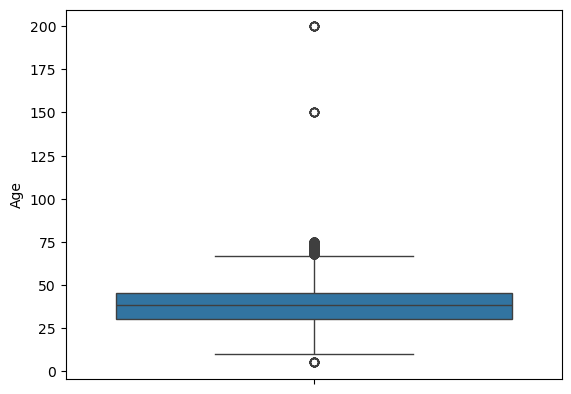

In [16]:
# Found some invalid Age inputs
sns.boxplot(df["Age"])

In [17]:
# Finding the invalid inputs indexes and setting them to NaN
df.loc[df["Age"] > 100, "Age"] = np.nan

# Changing the NaN to median
df["Age"] = df["Age"].fillna(df["Age"].median())

In [18]:
# Check
df["Age"].describe()

count    50000.00000
mean        37.75700
std         11.18107
min          5.00000
25%         30.00000
50%         38.00000
75%         45.00000
max         75.00000
Name: Age, dtype: float64

In [19]:
# Finding the invalid inputs indexes and setting them to NaN
df.loc[df["Total_Purchases"] < 0, "Total_Purchases"] = np.nan

# Changing the NaN to 0
df["Total_Purchases"] = df["Total_Purchases"].fillna(0)

# Data Profiling & Engeneering


Additional engineered features were also created to support segmentation and behavioral analysis, including:

- Customer Lifetime Value tiers
- Age groups
- Customer fidelity groups
- Churn status labels

In [20]:
# Rename the 0 and 1 for graphs
df["Churned"] = df["Churned"].map({
    0: "Active",
    1: "Churned"
})

# Question 1 What is the distribution of customer lifetime value?

## Objective

The first step of the analysis consists of understanding how customer value is distributed across the customer base. This allows us to identify concentration patterns, detect potential outliers, and evaluate whether customer value is evenly distributed or concentrated among a smaller subset of customers.

Understanding the CLV distribution also provides the foundation for the segmentation analyses developed in the following sections.

In [4]:
# SQL query
query = "SELECT Lifetime_Value FROM data"

# use pandas to read the query and save into a table
table = pd.read_sql_query(query,database)
table.describe()

,Lifetime_Value
count,50000.000000
mean,1440.626292
std,907.249443
min,0.000000
25%,789.817500
50%,1243.415000
75%,1874.000000
max,8987.240000


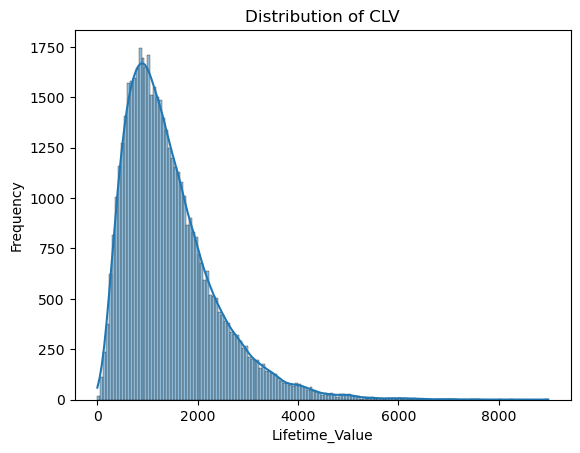

In [6]:
# Plotting the distribution of CLV
sns.histplot(table["Lifetime_Value"], kde=True)
plt.ylabel("Frequency")
plt.title('Distribution of CLV')
plt.show()

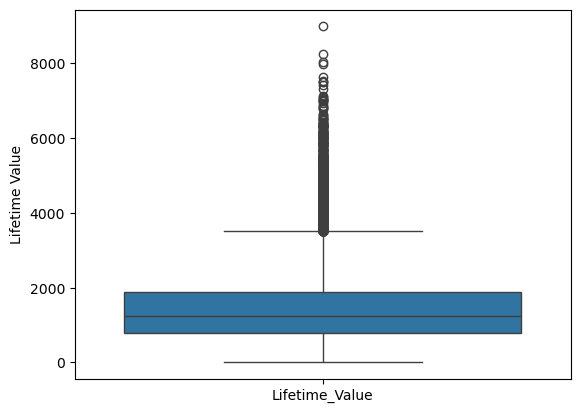

In [ ]:
# Plotting the boxplot to show possible outliers in the dataset
sns.boxplot(table)
plt.ylabel("Lifetime Value")
plt.show()

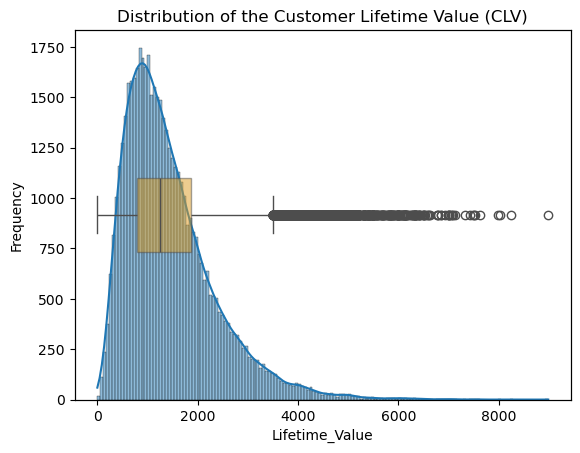

In [ ]:
# Ploting both boxplot and histplot together to have a better overview

fig, ax = plt.subplots()

# Histogram
figure = sns.histplot(table["Lifetime_Value"], kde=True, ax=ax)
plt.ylabel('Frequency')

# Create second axis sharing x-axis
ax2 = ax.twinx()

# Boxplot (horizontal, placed above along y)
sns.boxplot(
    x=table["Lifetime_Value"],
    ax=ax2,
    width=0.2,
    color = 'orange',
    boxprops=dict(alpha=0.5),  # transparency
)

# Hide second y axis
ax2.set_yticks([])
ax2.set_ylabel("")

# Title
plt.title("Distribution of the Customer Lifetime Value (CLV)")

# Save as png
figure.figure.savefig('CLV_distribution.png')
plt.show()

In [47]:
table.skew()

Lifetime_Value    1.447403
dtype: float64

<div class="alert alert-primary" style = "background-color:#dbeeff;border-radius:10px;border-width:3px;border-color:darkblue;font-family:Verdana,sans-serif;font-size:16px;color:#0b3d91"> 

## Insights & Interpretation
The distribution of Customer Lifetime Value (CLV) is strongly right-skewed (1.45), indicating that the majority of customers generate relatively moderate value while a smaller portion of customers contributes disproportionately high value levels.

Most customers are concentrated within a lower-to-mid CLV range between approximately 800 and 2000. However, the presence of high-value outliers extending beyond 4000 demonstrates the existence of a smaller group of exceptionally valuable customers.

The boxplot further highlights this imbalance through the large number of observations identified as outliers on the upper end of the distribution. This suggests that customer value is not evenly distributed across the customer base and that a limited number of customers may contribute a significant share of overall revenue.

From a business perspective, these findings support the relevance of customer segmentation strategies. High-value customers represent a strategically important segment that may benefit from targeted retention and loyalty initiatives, while the broader customer base may require different engagement approaches aimed at increasing long-term value.
</div>

# Question 2 Who are the highest-value customers?

## Objective

After analyzing the overall distribution of Lifetime Value, customers are segmented into different value tiers. This segmentation enables the identification of distinct customer groups and facilitates comparisons between low-value, medium-value, and high-value customers.

The purpose of this analysis is to better understand how customer behaviors and characteristics differ across value segments.


In [358]:
# Question 2: Customer Segmentation
# Set the thresholds to 33% and 66%
q1 = table["Lifetime_Value"].quantile(0.33)
q2 = table["Lifetime_Value"].quantile(0.66)

# Create a function to run on the LV column
def segment(lifetime):
    # Assign Tier III for lowest LVs
    if lifetime < q1:
        return "Tier III"
    # Assign Tier II for medium LVs
    elif lifetime < q2:
        return "Tier II"
    # Assign Tier I for highest LVs
    else:
        return "Tier I"

# Apply the function to the column
table["LV_Tier"] = table["Lifetime_Value"].apply(segment)
table

,Lifetime_Value,LV_Tier
0,953.33,Tier II
1,1067.47,Tier II
2,1289.75,Tier II
3,2340.92,Tier I
4,3041.29,Tier I
...,...,...
49995,2365.98,Tier I
49996,1293.60,Tier II
49997,1655.28,Tier I
49998,1286.11,Tier II


In [25]:
df.count(), table.count()

(Age                              50000
 Gender                           50000
 Country                          50000
 City                             50000
 Membership_Years                 50000
 Login_Frequency                  50000
 Session_Duration_Avg             50000
 Pages_Per_Session                50000
 Cart_Abandonment_Rate            50000
 Wishlist_Items                   50000
 Total_Purchases                  50000
 Average_Order_Value              50000
 Days_Since_Last_Purchase         50000
 Discount_Usage_Rate              50000
 Returns_Rate                     50000
 Email_Open_Rate                  50000
 Customer_Service_Calls           50000
 Product_Reviews_Written          50000
 Social_Media_Engagement_Score    50000
 Mobile_App_Usage                 50000
 Payment_Method_Diversity         50000
 Lifetime_Value                   50000
 Credit_Balance                   50000
 Churned                          50000
 Signup_Quarter                   50000


In [359]:
# can't merge on Lifetime Value it raises a many to many problem and creates more rows.
# I have to use the index for both table and merge on that

df["Customer_ID"] = df.index
table["Customer_ID"] = table.index

# Merge the Tiers to df
df = df.merge(table[["Customer_ID", "LV_Tier"]],
              on="Customer_ID",
                how='left')

# Update the database to call LV_Tier in SQL queries
df.to_sql("data_with_LV_tier", database, if_exists="replace", index=False)


50000

In [115]:
# Check if the merge succeeded
df["LV_Tier"].isna().sum()

np.int64(0)

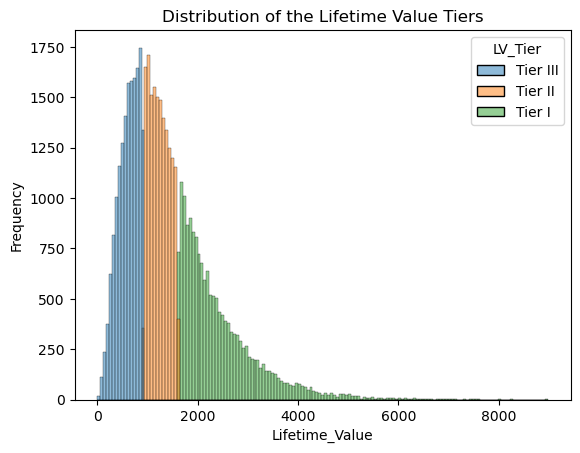

In [ ]:
figure = sns.histplot(data = df, x="Lifetime_Value", hue="LV_Tier", hue_order=["Tier III", "Tier II", "Tier I"], palette = 'tab10')
plt.ylabel('Frequency')
plt.title('Distribution of the Lifetime Value Tiers')
figure.figure.savefig("./graphs/LV_Tier.png")
plt.show()

C:\Users\vince\AppData\Local\Temp\ipykernel_15804\3091321786.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="LV_Tier",order=["Tier III", "Tier II", "Tier I"],palette = 'tab10')


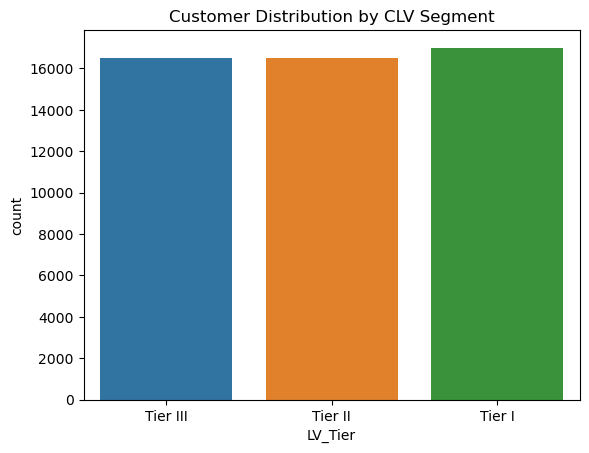

In [30]:
sns.countplot(data=df,x="LV_Tier",order=["Tier III", "Tier II", "Tier I"],palette = 'tab10')
plt.title("Customer Distribution by CLV Segment")
plt.show()

C:\Users\vince\AppData\Local\Temp\ipykernel_15804\308079428.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x="LV_Tier", y="Lifetime_Value", order = ["Tier III", "Tier II", "Tier I"], palette = 'tab10')


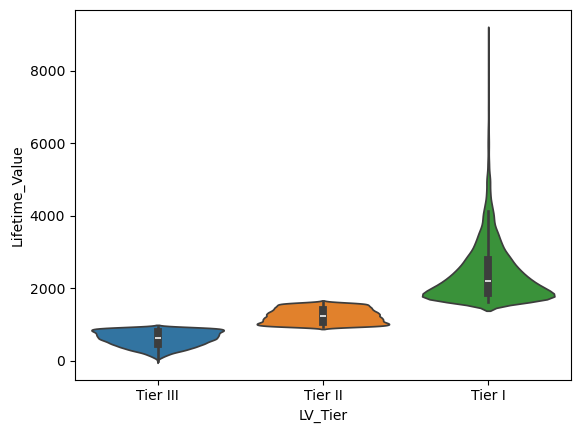

In [31]:
sns.violinplot(data = df, x="LV_Tier", y="Lifetime_Value", order = ["Tier III", "Tier II", "Tier I"], palette = 'tab10')
plt.show()

C:\Users\vince\AppData\Local\Temp\ipykernel_15804\3950805572.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = LV_per_tier, x="LV_Tier", y="Lifetime_Value", order=["Tier III", "Tier II", "Tier I"],palette = 'tab10')


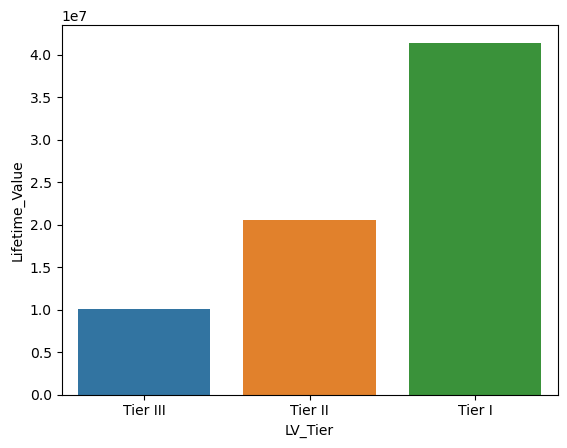

In [116]:
# Question 2bis: How much each tier represent in Revenue ?
# Group by customer Tier to study the influence of each parameter

LV_per_tier = df.groupby("LV_Tier")["Lifetime_Value"].sum().reset_index()
LV_per_tier

sns.barplot(data = LV_per_tier, x="LV_Tier", y="Lifetime_Value", order=["Tier III", "Tier II", "Tier I"],palette = 'tab10')
plt.show()

In [117]:
# transform in ratio
LV_per_tier['Ratio'] = round((LV_per_tier["Lifetime_Value"] / LV_per_tier["Lifetime_Value"].sum() * 100))
print(LV_per_tier)


    LV_Tier  Lifetime_Value  Ratio
0    Tier I     41436914.14   58.0
1   Tier II     20514323.79   28.0
2  Tier III     10080076.67   14.0


In [360]:
# SQL query
query = "SELECT LV_Tier, COUNT(LV_Tier) FROM data_with_LV_tier GROUP BY LV_Tier"

# use pandas to read the query and save into a table
table = pd.read_sql_query(query,database)
table

,LV_Tier,COUNT(LV_Tier)
0,Tier I,17000
1,Tier II,16501
2,Tier III,16499


C:\Users\vince\AppData\Local\Temp\ipykernel_15804\3175751307.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  figure = sns.barplot(data = LV_per_tier, x="LV_Tier", y="Ratio", order=["Tier III", "Tier II", "Tier I"],palette = 'tab10')


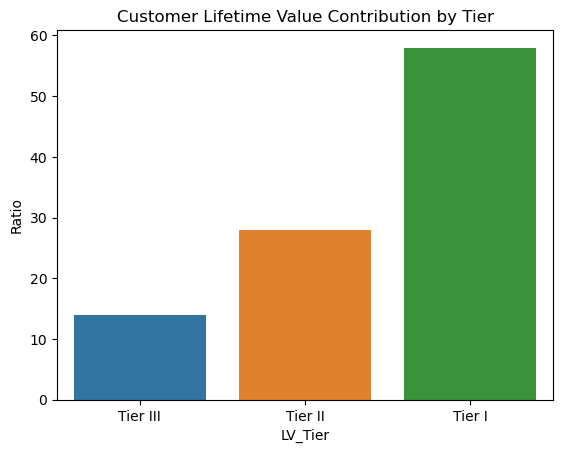

In [ ]:
figure = sns.barplot(data = LV_per_tier, x="LV_Tier", y="Ratio", order=["Tier III", "Tier II", "Tier I"],palette = 'tab10')
plt.title("Customer Lifetime Value Contribution by Tier")
figure.figure.savefig("./graphs/CLV_ratio.png")
plt.show()

<div class="alert alert-primary" style = "background-color:#dbeeff;border-radius:10px;border-width:3px;border-color:darkblue;font-family:Verdana,sans-serif;font-size:16px;color:#0b3d91"> 

## Insights & Interpretation

The customers have been segmented into 3 equally populated Tiers:
* <span style="color:blue;">**Tier III**</span> representing the low-value customers
* <span style="color:orange;">**Tier II**</span> representing the medium-value customers
* <span style="color:green;">**Tier I**</span> representing the high-value customers

Although these Tiers have very close population, the participation to the total Customer Lifetime Value differs. Tier III (low-value customers) accounts for about 14% of the total CLV while Tier II represents 28%. The high-value customers of Tier I account for 58% and therefore bring more than half the total CLV.

This segmentation allows a clearer understanding of the different groups of customers and a better definition of potential target group for Marketing campaigns. One option would be to focus on Tier III customers to understand what are the limitations that prevent them for contributing more to the total CLV. Another strategy would be to focus on Tier I customers to understand the factors that positively influence their experience and promote sales (higher CLV).
</div>


# Question 3 What factors are associated with higher lifetime value?

## Objective

This section investigates the variables most strongly associated with higher Customer Lifetime Value. Behavioral and transactional metrics are analyzed to determine which customer activities correlate with increased long-term value.

Correlation analysis and scatterplot visualizations are used to identify potential trends and relationships between customer behavior and CLV.


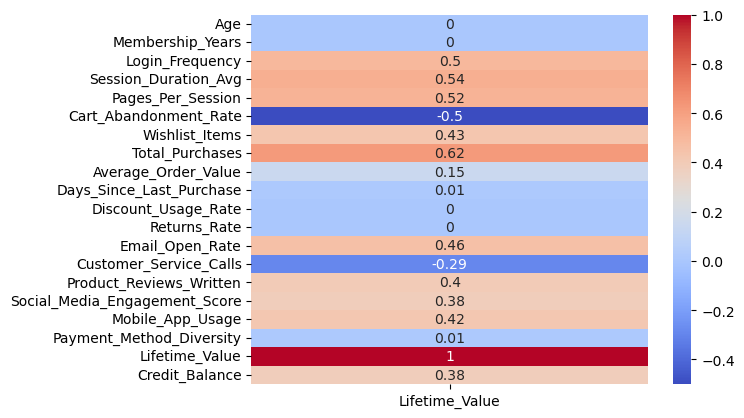

In [21]:
# Plot for only the Lifetime_Value
figure = sns.heatmap(df.corr(numeric_only= True)[["Lifetime_Value"]].round(2),annot=True,cmap="coolwarm")
figure.figure.savefig('./graphs/Correlation_CLV.png')
plt.show()

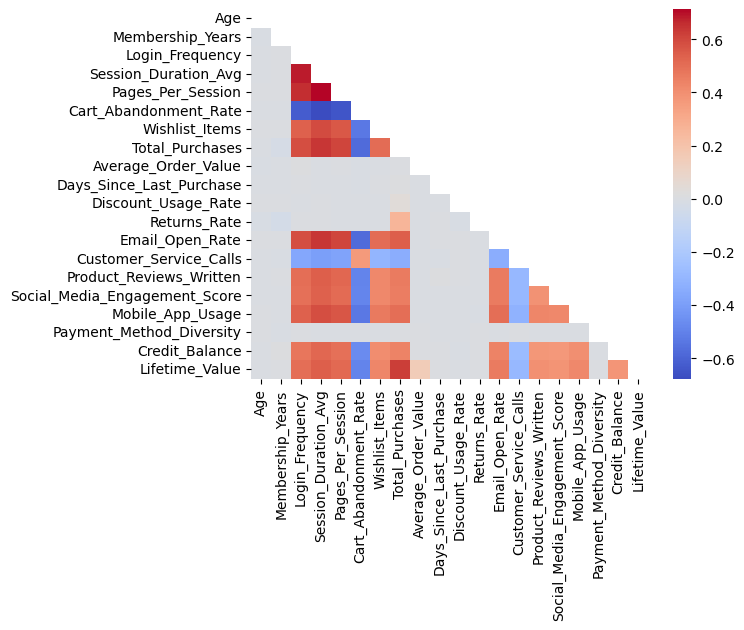

In [120]:
# Test will all numeric values
num_features = ['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
       'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items',
       'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Credit_Balance']

corr_matrix = df[num_features + ["Lifetime_Value"]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
#plt.figure(figsize=(35,25))
sns.heatmap(corr_matrix,mask = mask, annot=False,cmap="coolwarm")
#sns.heatmap(df[num_features + ["Lifetime_Value"]].corr(),annot=False,cmap="coolwarm")
plt.show()

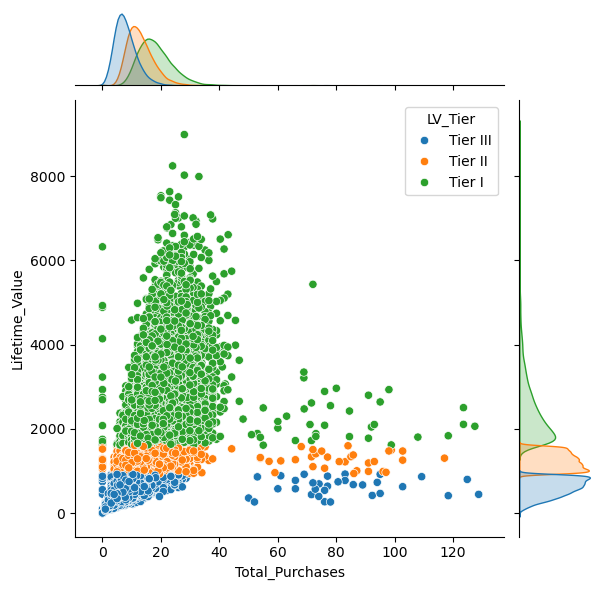

In [ ]:
#sns.regplot(data=df, x="Total_Purchases", y="Lifetime_Value", scatter_kws={"alpha": 0.3})
figure = sns.jointplot(data=df,y="Lifetime_Value", x="Total_Purchases", hue='LV_Tier', hue_order=["Tier III", "Tier II", "Tier I"])
figure.figure.savefig('./graphs/total_purchases.png')
plt.show()

<div class="alert alert-primary" style = "background-color:#dbeeff;border-radius:10px;border-width:3px;border-color:darkblue;font-family:Verdana,sans-serif;font-size:16px;color:#0b3d91"> 

## Insights & Interpretation

The investigation of the influence of various parameters on the Lifetime Value shows a range of coefficients. The criteria showing the strongest correlation (coefficient > 0.5) are 'Total_Purchases', 'Pages_Per_Session', 'Session_Duration_Avg','Login_Frequency'. All these parameters exhibit a postivie correlation meaning the higher those values, the higher the Lifetime Value. Such result is expected since those categories reflect the engagement of the customer with the e-commerce. On the opposite one may notice the strong negative correlation between 'Cart_Abandonment_Rate' and the Lifetime Value, the higher the abandonment rate, the lower the Lifetime Value of the customer. This is directly explained by the fact that abandonned cart do not convert resulting in lower Lifetime Value.

When looking at the strongest relationship, 'Total_Purchase' vs Lifetime Value, one may notice a strong increase of the Lifetime Value for lower number of purchases. The Lifetime Value increases strongly until the number of purchase crosses a threshold of about 40. Beyond this value, the relationship becomes much more dispersed. This behavior is observed for all customer Tiers.

An idea could be to investigate why the behavior changes drastically around this specific value. 

</div>

# Question 4 How do high-value customers behave differently?

## Objective

Following the customer segmentation process, this section focuses on identifying how customer behavior varies across Lifetime Value tiers. Engagement metrics, browsing activity, and shopping behavior are compared between segments to determine which behaviors characterize high-value customers.

This analysis helps reveal actionable behavioral patterns that may contribute to customer value creation.


In [189]:
# Question 4

query = "SELECT LV_Tier, AVG(Login_Frequency) AS avg_login," \
"AVG(Session_Duration_Avg) AS avg_session, " \
"AVG(Wishlist_Items) AS avg_wishlist " \
"FROM data_with_LV_tier " \
"GROUP BY LV_Tier;"

table = pd.read_sql_query(query,database)
table.describe()


,avg_login,avg_session,avg_wishlist
count,3.000000,3.000000,3.000000
mean,11.578144,27.534642,3.937827
std,4.588645,6.647012,1.648173
min,7.045639,20.992533,2.308200
25%,9.256745,24.161056,3.104770
50%,11.467850,27.329580,3.901339
75%,13.844396,30.805696,4.752640
max,16.220941,34.281812,5.603941


In [180]:
num_tier = df.groupby('LV_Tier').mean(numeric_only=True)

num_tier.columns

Index(['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
       'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items',
       'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Customer_ID', 'Engagement_Score'],
      dtype='object')

C:\Users\vince\AppData\Local\Temp\ipykernel_15804\3451716037.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\vince\AppData\Local\Temp\ipykernel_15804\3451716037.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\vince\AppData\Local\Temp\ipykernel_15804\3451716037.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\vince\AppData\Local\Temp\ipykernel_15804\3451716037.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

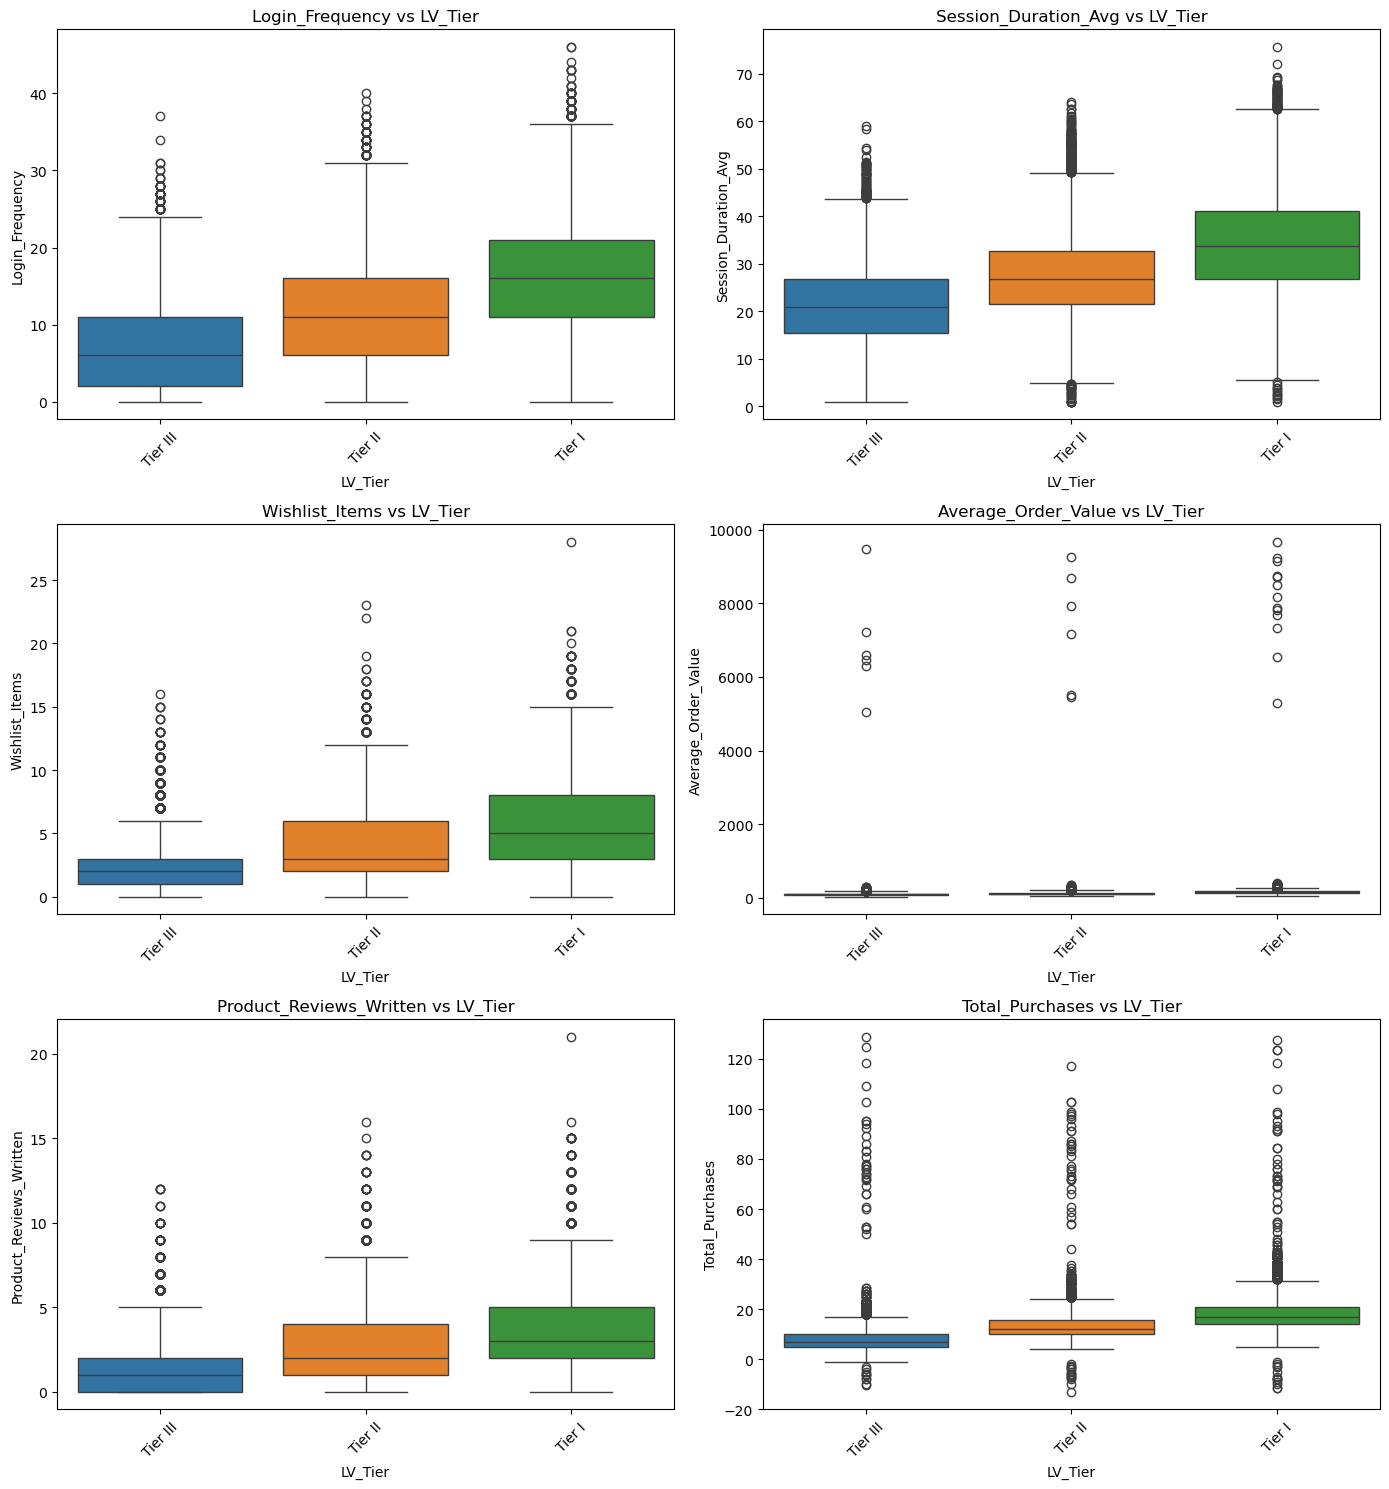

In [254]:
columns = ["Login_Frequency", "Session_Duration_Avg", "Wishlist_Items","Average_Order_Value", "Product_Reviews_Written", "Total_Purchases"]        
# set dimension of the grid
n = len(columns)

cols = 2
rows = math.ceil(len(columns) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()


for i, feature in enumerate(columns):
    sns.boxplot(
        data=df,
        x="LV_Tier",
        y=feature,
        ax=axes[i],
        order=["Tier III", "Tier II", "Tier I"],
        palette = 'tab10'
    )
    axes[i].set_title(f"{feature} vs LV_Tier")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<div class="alert alert-primary" style = "background-color:#dbeeff;border-radius:10px;border-width:3px;border-color:darkblue;font-family:Verdana,sans-serif;font-size:16px;color:#0b3d91"> 

## Insights & Interpretation

The investigation of the effects of the different categories previously determined to have a non-negligible correlation coefficient with the Lifetime Value allows to draw a few conclusions about the different customers Tiers.

* **Login_Frequency**: Tier III shows the lowest median while Tier I shows the highest, this tends to shows that high-value customers interact with the e-commerce more frequently. The increased spread for Tier I also indicates that some Tier I customers are very active.
* **Session_Duration_Avg**: Shows the same trends as Login_Frequency. Tier I customers spend more time per session, they spend more time during each interaction with the e-commerce.
* **Wishlist_Items**: Here again the trend is maintained, Tier I customers save more items which shows that Tier I customer appear more exploratory and more invested in the plaftorm than other Tiers.
* **Product_Reviews_Written**: Here again, Tier I customers write more reviews. Since the review system is volontary it reflects that Tier I customer are also active contributors to the platform.
* **Total_Purchases**: The high number of outliers and their spread between all tiers confirms that the segmentation is aligned with the purchase behavior and that some Tier III customers can also have high purchases counts (not exclusive to Tier I).
* **Average_Order_Value**: Massive number of outliers with a large spread in all Tiers. Tier I customers may not always spend more per order but they purchase more often and are more engaged with the platform.


This analysis sheds light on the different behaviors of the customers inside each Tier. Tier III customers tend to show low engagement with the platform with fewer purchases and lower sessions. Tier II customers show moderate engagement and activity. Tier I customers are higly engaged and active members of the platform, they interact more and longer.

</div>

# Question 5 What drives customer engagement?

## Objective

Customer engagement plays a critical role in retention and value generation. This section investigates the relationships between engagement-related metrics such as session activity, browsing behavior, and interaction frequency.

The goal is to determine which variables are most closely associated with stronger customer engagement patterns.


In [309]:
# Question 5
# Defining Engagement:
# Engagement_Score = Login_Frequency + Session_Duration_Avg + Pages_Per_Session

df["Engagement_Score"] = (df["Login_Frequency"] + df["Session_Duration_Avg"] + df["Pages_Per_Session"])

<Axes: >

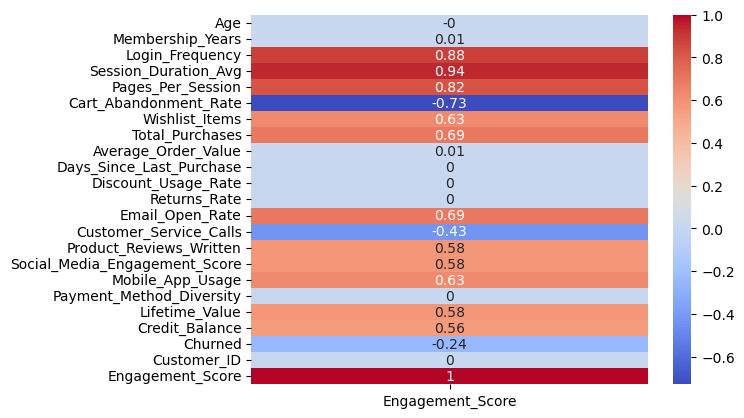

In [45]:
# Check correlation

sns.heatmap(df.corr(numeric_only= True)[["Engagement_Score"]].round(2),annot=True,cmap="coolwarm")


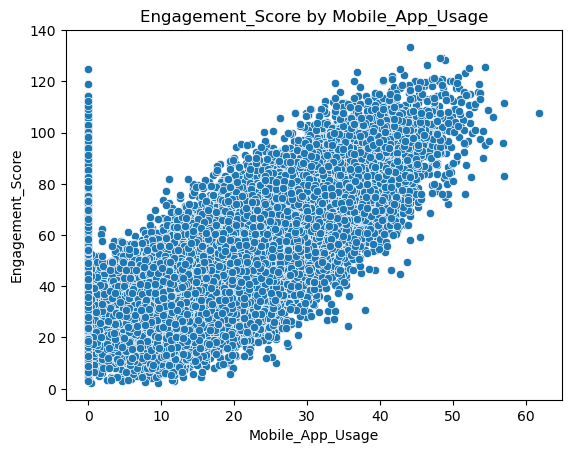

In [ ]:
figure = sns.scatterplot(data=df,y="Engagement_Score", x="Mobile_App_Usage")
plt.title('Engagement_Score by Mobile_App_Usage')
figure.figure.savefig('./graphs/mobile_app.png')
plt.show()

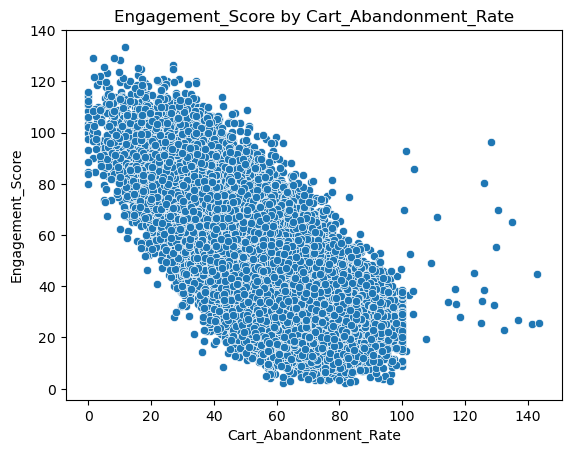

In [ ]:
figure = sns.scatterplot(data=df, x="Cart_Abandonment_Rate", y="Engagement_Score")
plt.title("Engagement_Score by Cart_Abandonment_Rate")
figure.figure.savefig("./graphs/cart_abandonment.png")
plt.show()

<div class="alert alert-primary" style = "background-color:#dbeeff;border-radius:10px;border-width:3px;border-color:darkblue;font-family:Verdana,sans-serif;font-size:16px;color:#0b3d91"> 

## Insights & Interpretation

The Engagement Score allows to regroup several criteria together and account and try to quantify the engagement of the customers with the platform. When looking at the correlation between the Engagement Score and the other categories, one may disregard the extremely high coefficients between the Login_Frequency, Session_Duration_Avg and Pages_Per_Session and the Engagement Score since these parameters define the Engagement Score. 

Contrary to the previous similar analysis with the Lifetime Value, the coefficients are much higher suggestion that this score is much more sensible to variations than the Lifetime Value. In the same fashion as for the Lifetime Value, a strong negative correlation exists between the Engagement Score and the Cart_Abandonment_Rate. The higher the abandonment rate the lower the engamgement score, which reflects the incomplete checkout process that is left out by the customer. 

On the opposite, one interesting factor to investigate is the Mobile_App_Usage that exhibit a strong positive correlation with the Engagement Score. This suggest that the more the customer uses the mobile app, the more it interacts with the platform.

Such information can be used to push marketing campaign targeting mobile users to attract and retain new and old customers.


</div>

# Question 6 What factors influence churn?

## Objective

Customer churn represents a major business challenge. In this section, numerical behavioral variables are analyzed to identify differences between active and churned customers.

The analysis focuses on variables related to customer activity, purchasing behavior, and platform engagement in order to detect potential churn indicators.


In [71]:
# Question 6

churned = df.groupby("Churned").mean(numeric_only=True)
churned

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Customer_ID,Engagement_Score
Churned,,,,,,,,,,,,,,,,,,,,,,
Active,38.552011,2.984828,12.642391,29.071314,9.242450,54.194460,4.324641,13.827522,118.383907,26.541322,42.846339,5.896148,22.790262,5.169705,2.906779,28.090937,18.634875,2.332883,1446.805875,2067.570408,24963.296315,50.956155
Churned,35.994187,2.981996,9.120830,23.988014,7.426159,64.178935,3.043945,11.350201,134.762532,35.966851,39.473752,6.535197,16.164401,6.875709,2.030657,20.304754,14.481142,2.344291,1425.423236,1690.190450,25088.568581,40.535003


C:\Users\vince\AppData\Local\Temp\ipykernel_15804\2382325103.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  figure = sns.boxplot(
C:\Users\vince\AppData\Local\Temp\ipykernel_15804\2382325103.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  figure = sns.boxplot(
C:\Users\vince\AppData\Local\Temp\ipykernel_15804\2382325103.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  figure = sns.boxplot(
C:\Users\vince\AppData\Local\Temp\ipykernel_15804\2382325103.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

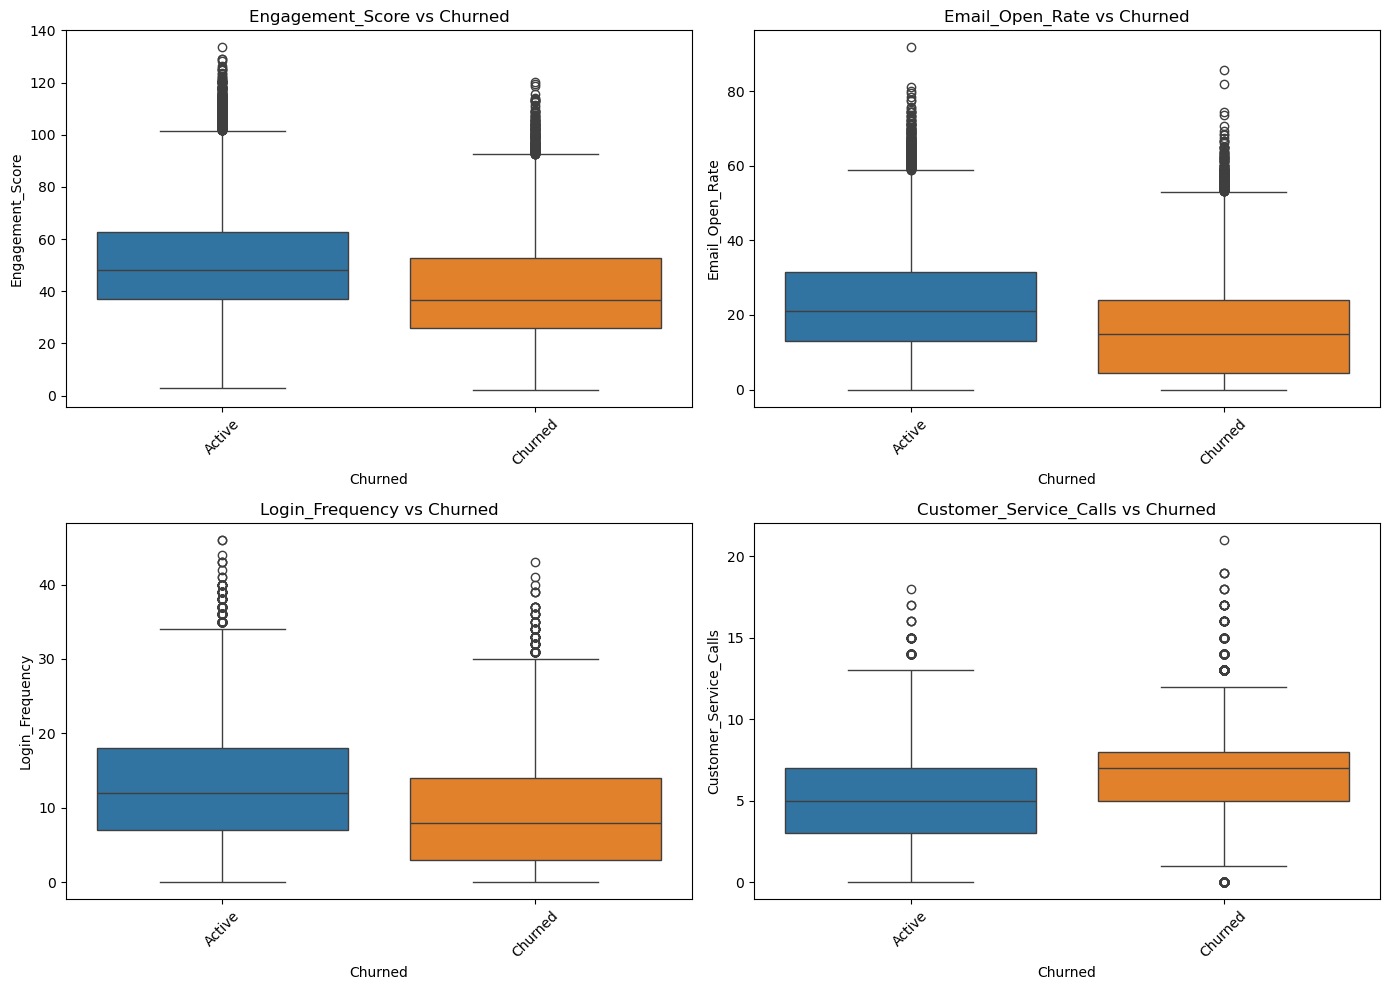

In [ ]:
columns = ["Engagement_Score", "Email_Open_Rate", "Login_Frequency", "Customer_Service_Calls"]
           
# set dimension of the grid
n = len(columns)

cols = 2
rows = math.ceil(len(columns) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()


for i, feature in enumerate(columns):
    figure = sns.boxplot(
        data=df,
        x="Churned",
        y=feature,
        ax=axes[i],
        palette = 'tab10'
    )
    axes[i].set_title(f"{feature} vs Churned")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
figure.figure.savefig("./graphs/plots.png")
plt.show()

<div class="alert alert-primary" style = "background-color:#dbeeff;border-radius:10px;border-width:3px;border-color:darkblue;font-family:Verdana,sans-serif;font-size:16px;color:#0b3d91"> 

## Insights & Interpretation

The investigation of the effects of the different categories on churned customers allows us to better identify them.

* **Engagement_Score**: Active customers are more engaged with a higher median, higher upper quartiles than churned customers who show lower median and distribution. The customers who remain active tend to interact more deeply with the platform.
* **Email_Open_Rate**: Active customers open emails more frequently and show stronger marketing interaction while churned customers have lower opening rates. Customers disengaging from communication channels are more likely to churn.
* **Login_Frequency**: Active users login more often, reduced platform usage is associated with churn.
* **Customer_Service_Calls**: Churned customers show higher values. Customers contacting the support are more likely to churn.

Customers who churn tend to be significantly less engaged with the platform, while simultaneously requiring more customer support interactions.

</div>

# Question 7 Relationship between customer churn and categorical behavioral features?

## Objective

This section investigates whether categorical customer attributes exhibit statistically significant relationships with churn behavior.

Chi-square testing and Cramér’s V analysis are used to evaluate the strength of association between churn and several categorical features. The purpose is to determine whether demographic or categorical variables meaningfully influence churn patterns within the dataset.

In [298]:
cat.columns

Index(['Gender', 'Country', 'City', 'Signup_Quarter'], dtype='object')

In [155]:
# Question 7
# Checking gender, Churned
crosstab = pd.crosstab(df.Gender, df.Churned)
crosstab

Churned,Active,Churned
Gender,,
Female,17839,7277
Male,17067,6880
Other,644,293


In [159]:
_, chi2_pvalue, _, _ = chi2_contingency(crosstab)
print(chi2_pvalue.round(2)) # large value = no significant relationship

0.23


In [161]:
association(crosstab, method='cramer')  # low coeff = confirms weak/negligible relationship

0.007699194829283923

In [163]:
# Same for Signup_Quarter, churned
crosstab = pd.crosstab(df.Signup_Quarter, df.Churned)
_, chi2_pvalue, _, _ = chi2_contingency(crosstab)
cramer = association(crosstab, method='cramer')
print(f'Chi2 p-value: {chi2_pvalue.round(2)}')
print(f'Cramer coeff: {round(cramer,2)}')

Chi2 p-value: 0.03
Cramer coeff: 0.01


In [307]:
# Coefficents churned using function corr_coeff
corr_coeff(df.Payment_Method_Diversity, df.Churned)
corr_coeff(df.Signup_Quarter, df.Churned)
corr_coeff(df.Gender, df.Churned)

Chi2: 0.03 
Cramér's V: 0.01
Chi2: 0.03 
Cramér's V: 0.01
Chi2: 0.23 
Cramér's V: 0.01


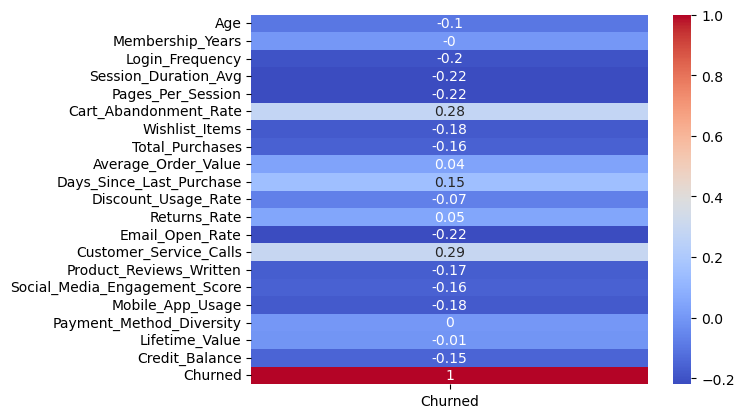

In [ ]:
# Check numeric features

figure = sns.heatmap(df.corr(numeric_only= True)[["Churned"]].round(2),annot=True,cmap="coolwarm")
figure.figure.savefig('./graphs/Correlation_CLV.png')
plt.show()

## Insights & Interpretation

*(Write your observations and conclusions here)*

---

# Question 8 What is the impact of customer tenure (membership years)?

## Objective

Customer loyalty and membership duration are often considered important indicators of long-term value and retention. This section evaluates how customer fidelity influences both Lifetime Value and churn behavior.

Customers are grouped according to membership duration in order to compare value generation and retention patterns across loyalty levels.


In [316]:
# Question 8
# Impact of fidelity on engagement, churn risk and value
df["Fidelity"] = pd.cut(
    df["Membership_Years"],
    bins=[0,2,5,9,100],
    labels=["0-2","3-5","6-9","10+"]
)

df.to_sql("data_with_fidelity", database, if_exists="replace", index=False)

50000

In [340]:
query = "SELECT Fidelity, AVG(Lifetime_Value) as avg_clv, COUNT(*) as count " \
"FROM data_with_fidelity " \
"GROUP BY Fidelity ORDER BY Fidelity;"
table = pd.read_sql_query(query,database)
table

,Fidelity,avg_clv,count
0,0-2,1441.152078,19841
1,10+,1469.158402,870
2,3-5,1437.380656,22606
3,6-9,1446.329686,6683


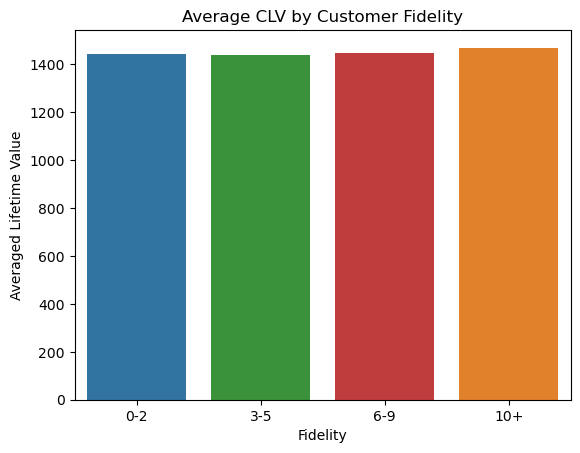

In [ ]:
figure = sns.barplot(data=table, x="Fidelity", y="avg_clv", hue = "Fidelity", order=["0-2","3-5","6-9","10+"], palette = "tab10")
plt.title("Average CLV by Customer Fidelity")
plt.ylabel("Averaged Lifetime Value")
figure.figure.savefig("./graphs/Fidelity_CLV.png")
plt.show()

In [333]:
query = "SELECT Fidelity, Churned, COUNT(*) as count " \
"FROM data_with_fidelity " \
"GROUP BY Fidelity, Churned ORDER BY Fidelity;"
table = pd.read_sql_query(query,database)
table

,Fidelity,Churned,count
0,0-2,Active,14140
1,0-2,Churned,5701
2,10+,Active,616
3,10+,Churned,254
4,3-5,Active,16022
5,3-5,Churned,6584
6,6-9,Active,4772
7,6-9,Churned,1911


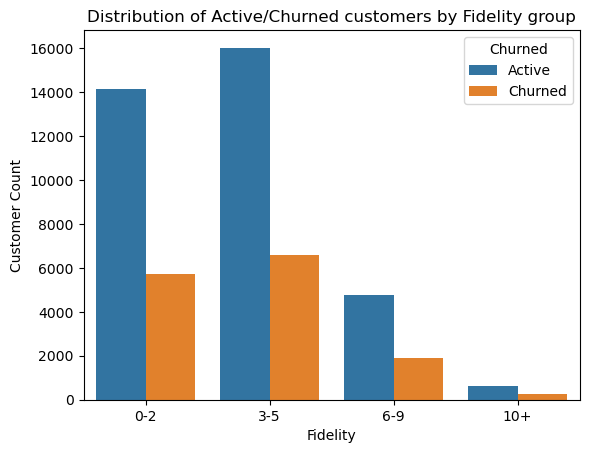

In [ ]:
figure = sns.barplot(data=table, x="Fidelity", y="count", hue = "Churned", order=["0-2","3-5","6-9","10+"], palette = "tab10")
plt.title("Distribution of Active/Churned customers by Fidelity group")
plt.ylabel('Customer Count')
figure.figure.savefig("./graphs/fidelity_churn.png")
plt.show()

## Insights & Interpretation

*(Write your observations and conclusions here)*

---

# Question 9 How do purchasing behaviors affect lifetime value?

## Objective

Purchasing activity is a key component of customer value generation. This section investigates how purchasing patterns such as order frequency and average order value relate to Customer Lifetime Value.

The objective is to identify which purchasing behaviors contribute most strongly to long-term customer profitability.


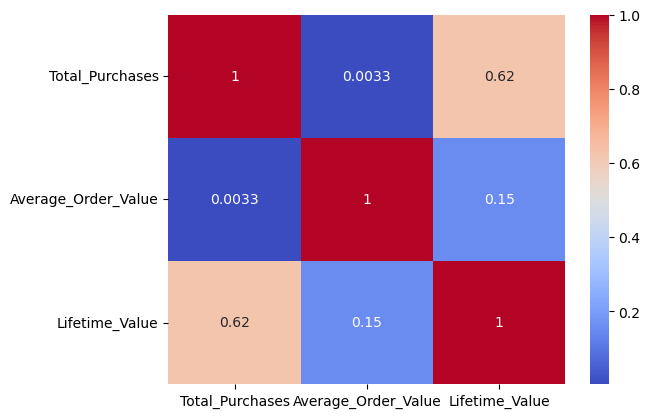

In [77]:
# Question 9:
# Link between AOV, purchase frequency and total value

sns.heatmap(df[["Total_Purchases", "Average_Order_Value", "Lifetime_Value"]].corr(), annot=True, cmap='coolwarm')
plt.show()


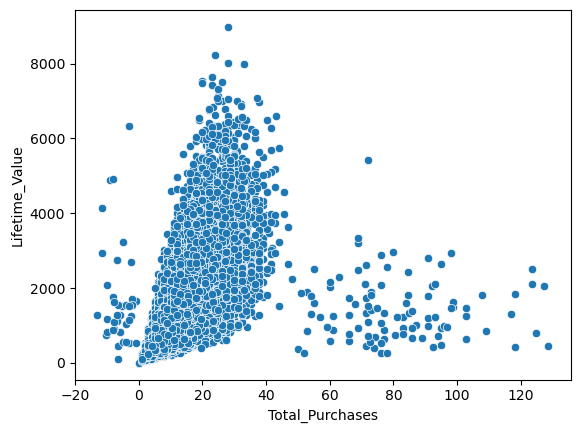

In [59]:
sns.scatterplot(data=df, x="Total_Purchases", y="Lifetime_Value")
plt.show()

In [207]:
df.Total_Purchases.describe()

count    50000.000000
mean        13.111576
std          7.017312
min        -13.000000
25%          8.000000
50%         12.000000
75%         17.000000
max        128.700000
Name: Total_Purchases, dtype: float64

In [206]:
query = "SELECT Total_Purchases, " \
"AVG(Lifetime_Value) as avg_ltv " \
"FROM data_with_LV_Tier " \
"GROUP BY Total_Purchases " \
"ORDER BY Total_Purchases; "
table = pd.read_sql_query(query,database)
table

,Total_Purchases,avg_ltv
0,-13.0,1282.050000
1,-11.7,3534.775000
2,-10.4,745.810000
3,-10.0,1358.753333
4,-9.1,4885.170000
...,...,...
145,118.3,1123.455000
146,123.5,2303.940000
147,124.8,797.880000
148,127.4,2060.230000


## Insights & Interpretation

*(Write your observations and conclusions here)*

---

# Question 10 How do demographics influence customer behavior and churn?

## Objective

The final section of the analysis examines the influence of demographic variables such as age and gender on customer value and churn behavior.

This analysis aims to determine whether certain demographic groups exhibit distinct value or retention patterns within the customer base.


In [361]:
# Question 10
# Creating Age groups
df["Age_Group"] = pd.cut(df["Age"], 
                bins=[0,19,29,39,49,59,69,200],
                labels=["<20","20-29","30-39","40-49","50-59","60-69","70+"]
                )


In [362]:
# Update the database to call Age_Group in SQL queries
df.to_sql("data_with_age_group", database, if_exists="replace", index=False)

50000

In [79]:
age_lifetime = df.groupby("Age_Group")["Lifetime_Value"].mean()
age_lifetime

C:\Users\vince\AppData\Local\Temp\ipykernel_15804\2496992095.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_lifetime = df.groupby("Age_Group")["Lifetime_Value"].mean()


Age_Group
<20      1444.308627
20-29    1435.994857
30-39    1441.211726
40-49    1445.460267
50-59    1439.793515
60-69    1420.496964
70+      1385.961640
Name: Lifetime_Value, dtype: float64

C:\Users\vince\AppData\Local\Temp\ipykernel_15804\3081082382.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  figure = sns.barplot(data = age_lifetime, palette = 'tab10')


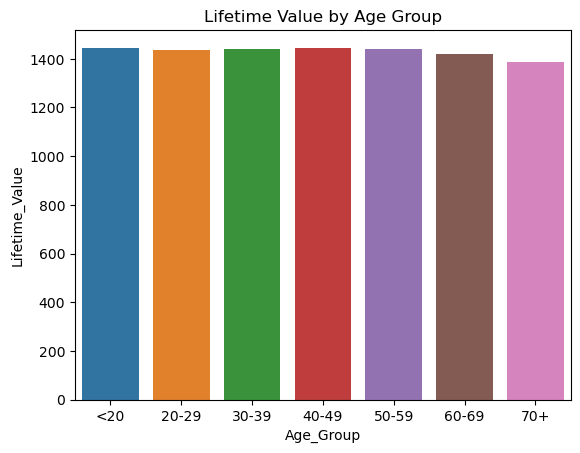

In [ ]:
figure = sns.barplot(data = age_lifetime, palette = 'tab10')
plt.title("Lifetime Value by Age Group")
figure.figure.savefig('./graphs/Age_group.png')
plt.show()


In [347]:
query = "SELECT Gender,AVG(Lifetime_Value) as avg_value " \
"FROM data_with_LV_Tier " \
"GROUP BY Gender;"
table = pd.read_sql_query(query,database)
table

,Gender,avg_value
0,Female,1442.153550
1,Male,1438.803539
2,Other,1446.272871


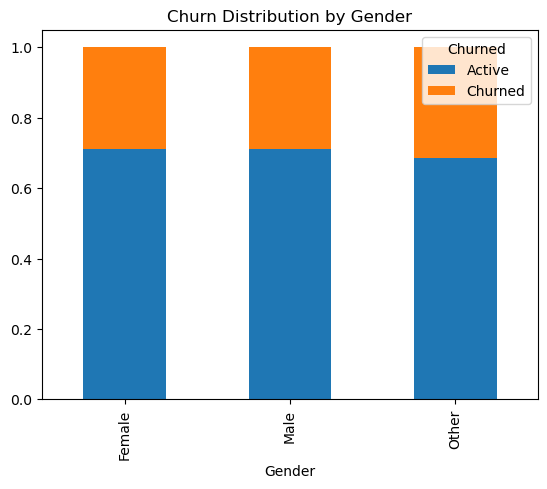

In [ ]:
# Influence of Gender on losing the customer or not
# Need to normalizze to account for the ratios between the genders
crosstab = pd.crosstab(
    df["Gender"],
    df["Churned"],
    normalize="index"
)
crosstab.plot(kind="bar", stacked=True)
# sns.countplot(data=df,x="Gender",hue="Churned")
plt.title("Churn Distribution by Gender")
plt.savefig('./graphs/Churn.png')
plt.show()

In [363]:
# Check Age group repartition in each LV_Tier

# SQL query
query = "SELECT LV_Tier, Age_Group, COUNT(*) as count FROM data_with_age_group GROUP BY LV_Tier, Age_Group;"

# use pandas to read the query and save into a table
table = pd.read_sql_query(query,database)
table

,LV_Tier,Age_Group,count
0,Tier I,20-29,2991
1,Tier I,30-39,5934
2,Tier I,40-49,4440
3,Tier I,50-59,2041
4,Tier I,60-69,446
5,Tier I,70+,60
6,Tier I,<20,1088
7,Tier II,20-29,2960
8,Tier II,30-39,5733
9,Tier II,40-49,4310


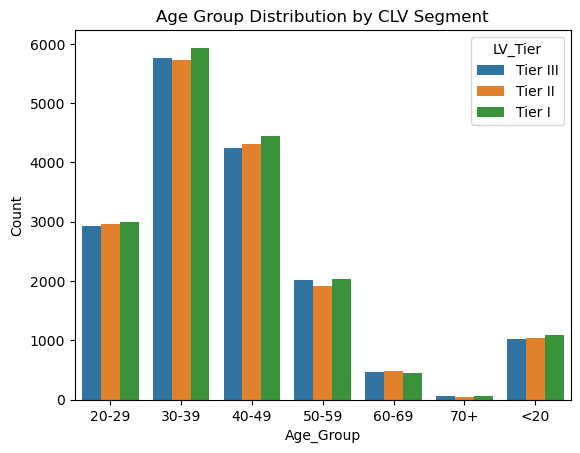

In [364]:
figure = sns.barplot(
    data=table,
    x="Age_Group",
    y="count",
    hue="LV_Tier",
    hue_order=["Tier III", "Tier II", "Tier I"]
)

plt.title("Age Group Distribution by CLV Segment")
plt.ylabel("Count")
figure.figure.savefig("./graphs/age_group_per_segment.png")
plt.show()

## Insights & Interpretation

*(Write your observations and conclusions here)*

---

# General Conclusion

## Summary of Findings

This project explored customer behavior, engagement, value generation, and churn dynamics through a combination of SQL querying, exploratory data analysis, statistical testing, and data visualization techniques.

The analysis identified several behavioral patterns associated with customer value and retention while also highlighting variables that exhibited limited predictive influence on churn behavior.

---

## Business Perspective

Understanding customer value drivers and churn indicators can help businesses:

- Improve customer retention strategies
- Identify high-value customer segments
- Optimize engagement initiatives
- Develop more targeted marketing campaigns
- Increase long-term profitability

The findings from this analysis provide a foundation for future predictive modeling and customer segmentation strategies.

---

## Final Remarks

Beyond the business insights generated, this project demonstrates a complete analytical workflow combining:

- Data cleaning
- Feature engineering
- SQL querying
- Exploratory data analysis
- Statistical testing
- Data visualization
- Business interpretation

The study showcases how data analytics can be leveraged to transform raw customer data into actionable strategic insights.